### Computational Guided Inquiry for PChem (Neshyba, 2026)

# Visualizing $H(T,P)$

## Introduction
The enthalpy of a gas can be approximated as 

$$
H(T,P) = [{5 \over 2}RT + f_{rot}(T) + f_{vib}(T) + f_{intermol}(T,P)] \times n \ \ \ (1)
$$ 

where, for a vdw gas, 

$$
f_{intermol}(T,P) \approx P(b - {{2a}\over{RT}}) \ \ \ (2)
$$

Other notes about this: 
- The term ${5 \over 2}RT$ comes from the fact that there's ${3 \over 2}RT$ in translational kinetic energy, plus $RT$ as an approximation to the $PV$ in $H=U+PV$. 
- The terms $f_{rot}(T)$ and $f_{vib}(T)$ are our old friends that appeared in $U(T,V)$.
- The slope of $H(T,P)$ in the temperature direction, $\bigl ( {\partial H \over \partial T} \bigr )_P$, is called the *constant-pressure heat capacity*, $C_P$.
- The slope of $H(T,P)$ in the pressure direction, $\bigl ( {\partial H \over \partial P} \bigr )_T$, is called the *isothermal Joule-Thomson coefficient*, $\mu_T$. 

## The twist
So much for the math ... what does $H(T,P)$ *look like*? That's what we'll be doing here: inspecting the enthalpy of a van der Waals gas as a thermodynamic surface, in a temperature/pressure state space. One thing you'll be able to see from this is that $H(T,P)$ has a kind of twist: at low temperatures, the slope in the pressure direction ($\mu_T$) is negative, but at a high enough temperature, that slope becomes positive. The temperature at which this transition happens is called the *inversion temperature*. 

## Isenthalps and the Joule-Thomson experiment
We'll be introducing in this exercise a new way of looking at those surfaces: contour plots. What are contour plots? If you're familiar with hiking around in mountains, you might have used *elevation contour* maps. Lines on elevation contour maps tell you paths of constant altitude. Likewise, contour plots of $H(T,P)$ show paths for which the *enthalpy* remains constant. Such paths even have a special term in the lingo of Thermodynamics: they're called *isenthalps*. 

It turns out that isenthalps are key to an experiment, called the *Joule-Thomson* experiment, in which a compressed gas (i.e., at high pressure) is allowed to escape through a throttle (see, e.g., https://chem.libretexts.org/@api/deki/files/113330/pic1.png?revision=1). In doing so, it turns out that the enthalpy of the gas remains constant -- i.e., the gas follows those isenthalps as it escapes through the throttle. By inspecting contours of $H(T,P)$, we can see how much the temperature is expected to change. We can also use contours of $H(T,P)$ to identify a key switch-over point, namely, the temperature at which isenthalps change from curving toward lower temperatures, to curving toward higher temperatures.

## van der Waals prediction of the inversion temperature
It turns out that in the case of a van der Waals gas, we can predict the inversion temperature by noting that, at the inversion temperature,

$$
\mu_T\approx b - {{2a}\over{RT}}=0 \ \ \ (3)
$$

and solving for the temperature. 

## Learning Goals
1. I can plot $H(T,P)$ for a given van der Waals gas, as a thermodynamic surface and as a contour map, and describe what an *isenthalp* is.
1. I can identify the inversion temperature from such plots.
1. I can use vdw theory to predict the inversion temperature of a gas.

In [5]:
# Import resources
import pint; from pint import UnitRegistry; AssignQuantity = UnitRegistry().Quantity
import warnings; warnings.filterwarnings("ignore", "The unit of the quantity is stripped when downcasting to ndarray")
import numpy as np
import matplotlib.pyplot as plt; plt.rc("figure", figsize=(15, 12));plt.rcParams['font.size'] = 24
import pchemlibrary as PL

### van der Waals parameters
Below, we define van der Waals parameters for a particular gas.

In [6]:
# Constants
R = AssignQuantity(8.314,'J/mol/K')
n = AssignQuantity(1,'mol')

# vdw parameters
a = AssignQuantity(3.640,'L^2 bar / mol^2'); print(a)
b = AssignQuantity(0.04267,'L /mol'); print(b)

3.64 bar * liter ** 2 / mole ** 2
0.04267 liter / mole


### Hunting for the inversion temperature
In the cell below, we create a new state space grid, in which temperature and pressure are the independent variables. This state space is constructed using the same Python function we've used before, PL.Statespace, but with input parameters that specify the range of temperatures and pressures (rather than temperatures and volumes, as we did previously). 

On that grid, we'll be looking at the enthalpy of a gas, given by Eq. 1, with $f_{vib}(T)=0$ (i.e., it's not vibrating), $f_{rot}(T)={2 \over 2}RT$, and $f_{intermolecular}$ given by Eq. 2. In fact, we're displaying this function in two ways: one is the usual 3d surface view, the other is a contour plot, in which lines of constant enthalpy, called *isenthalps*, are drawn.

Your task in this cell is to adjust the temperature range of the state space such that *the center of the temperature range equals (approximately) the inversion temperature of the gas.* This is a guess-and-check operation; a reasonable starting point would be room temperature, say

    T_center = 300

but that value will need to be adjusted.

Text(0, 0.5, 'P (bar)')

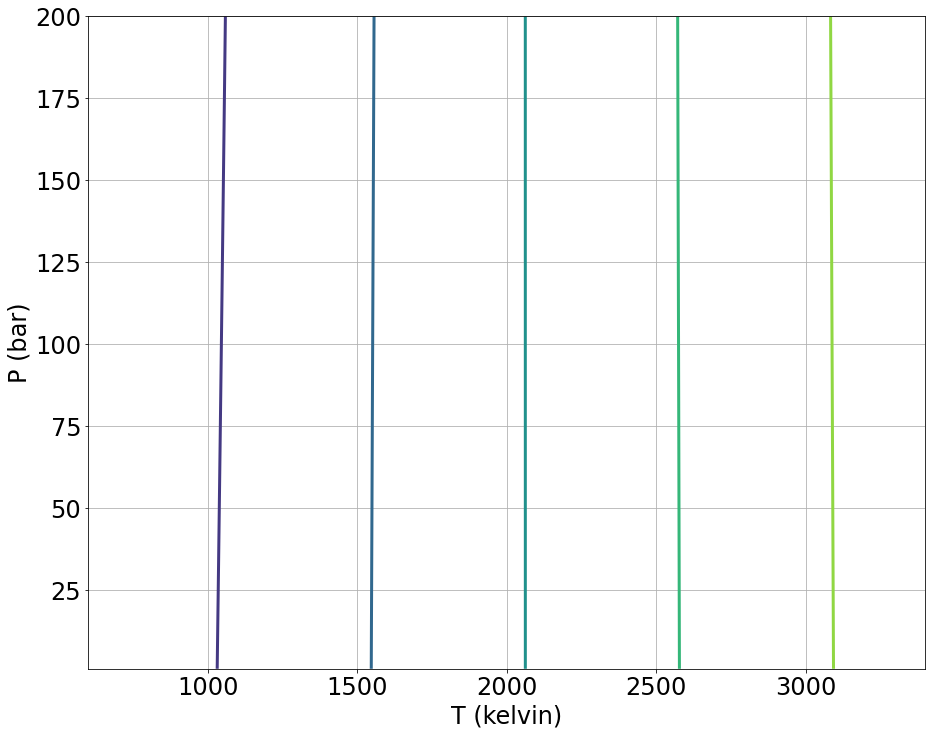

In [7]:
# Assign a value to T_center (the center of the temperature range for our state space)
### BEGIN SOLUTION
T_center = 2000
### END SOLUTION

# Specify  a range of temperatures around that to investigate
T_min = T_center*.3
T_max = T_center*1.7
number_of_temperatures = 100

# Also choose a range of pressures
P_min = 1
P_max = 200
number_of_pressures = 101

# Now make the state space
Tgrid,Pgrid = PL.Statespace([T_min, T_max, number_of_temperatures],[P_min, P_max, number_of_pressures])
Tgrid = AssignQuantity(Tgrid,'K')
Pgrid = AssignQuantity(Pgrid,'bar')

# Calculate H(T,P) for the gas
f_intermolecular = Pgrid*(b-2*a/(R*Tgrid))
H = (5/2*R*Tgrid + 2/2*R*Tgrid +f_intermolecular)*n

# Convert H to kJ
H.ito('kJ')

# Graphing as a thermodynamic surface
xlabel = 'T ('+str(Tgrid.units)+')'
ylabel = 'P ('+str(Pgrid.units)+')'
zlabel = 'H ('+str(H.units)+')'
llist = [xlabel,ylabel,zlabel]
PL.plot_surface(Tgrid, Pgrid, H, color='purple', title='H(T,P)',labellist=llist).show() 

# Graph it as a contour plot
plt.figure()
plt.grid(True)
plt.contour(Tgrid, Pgrid, H,linestyles='solid', linewidths=3)
plt.xlabel(xlabel)
plt.ylabel(ylabel)

### Pause for analysis
In the cell below, answer these questions:

1. Suppose our gas is initially at room temperature (say $300 \ K$), in a tank compressed to $200 \ bar$. We let some of it escape through a throttle to the lowest pressure indicated in our contour map (regular atmospheric pressure, $\approx 1 \ bar$). What does our contour map predict its temperature will be after passing through the throttle?
1. What is the value of the inversion temperature for this gas?
1. We've said this gas is non-vibrating, but -- based on our use of $f_{rot}(T)={2 \over 2}RT$ -- which of the following would you guess it is?

- An atomic gas (e.g., $Ne$ or $Ar$);
- A diatomic or linear gas (e.g., $N_2$ or $CO_2$); or 
- A polyatomic gas (e.g., $H_2O$)

### BEGIN SOLUTION

1. Looks like about 140 K
1. The inversion temperature is around 2000 K
1. It's a diatomic or linear gas

### END SOLUTION

### Comparing to an analytical result
In the cell below, use Eq. 3 to predict the inversion temperature for our gas (you'll have to convert to degrees kelvin).

20.521009257061102 bar * kelvin * liter / joule
2052.100925706111 kelvin
mu_JT = 1 kelvin / bar
mu_T = -0.29099 liter


Text(0, 0.5, 'P (bar)')

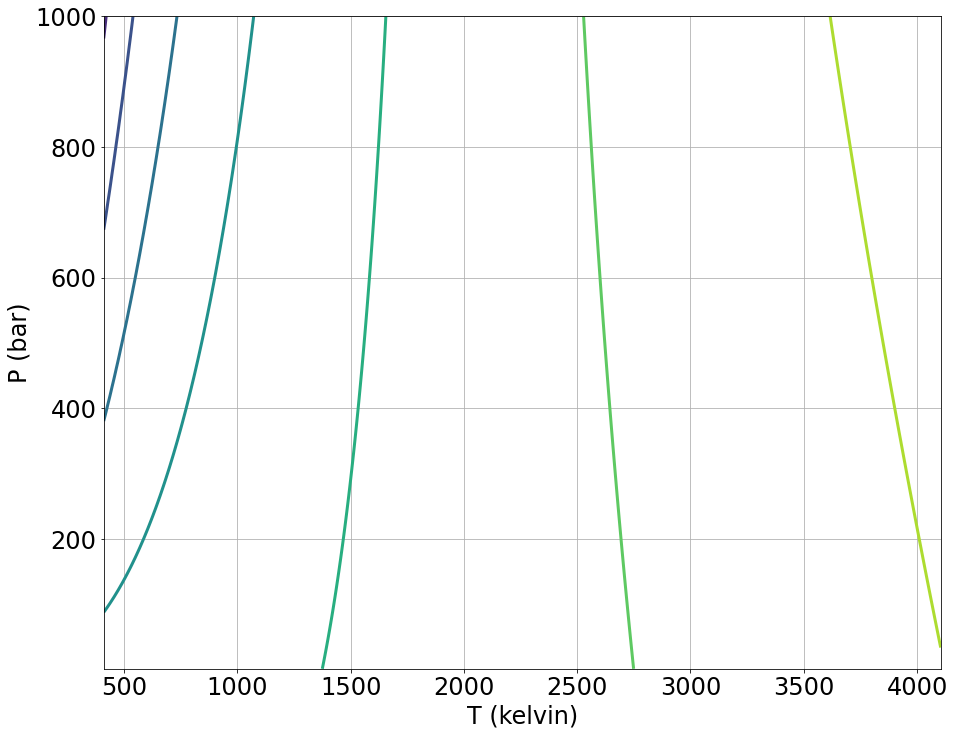

In [ ]:
### BEGIN SOLUTION
T_inv = 2*a/(R*b)
print(T_inv)
T_inv.ito('K')
print(T_inv)

# Not part of the solution, but calculating mu_T from experimental results
n = AssignQuantity(1,'mol')
R = AssignQuantity(8.314,'J/(mol K)')
Cp = 7/2*R*n
mu_JT = AssignQuantity(1,'K/bar'); print('mu_JT =', mu_JT)
mu_J = -Cp*mu_JT
mu_J.ito('L')
print('mu_T =', mu_J)

# Not part of the solution, but for presentation
abfactor = 8
a_display = a*abfactor
b_display = b*abfactor
T_min = T_inv*.2
T_max = T_inv*2
P_min = 1
P_max = 1000
number_of_temperatures = 200
number_of_pressures = 201

Tgrid,Pgrid = PL.Statespace([T_min, T_max, number_of_temperatures],[P_min, P_max, number_of_pressures])
Tgrid = AssignQuantity(Tgrid,'K')
Pgrid = AssignQuantity(Pgrid,'bar')

# Calculate H(T,P) for the gas
f_intermolecular = Pgrid*(b_display-2*a_display/(R*Tgrid))
H = (5/2*R*Tgrid + 2/2*R*Tgrid +f_intermolecular)*n

# Convert H to kJ
H.ito('kJ')

# Graphing as a thermodynamic surface
xlabel = 'T ('+str(Tgrid.units)+')'
ylabel = 'P ('+str(Pgrid.units)+')'
zlabel = 'H ('+str(H.units)+')'
llist = [xlabel,ylabel,zlabel]
PL.plot_surface(Tgrid, Pgrid, H, color='purple', title='H(T,P)',labellist=llist).show() 

# Graph it as a contour plot
plt.figure()
plt.grid(True)
plt.contour(Tgrid, Pgrid, H,linestyles='solid', linewidths=3)
plt.xlabel(xlabel)
plt.ylabel(ylabel)

### END SOLUTION

### Pause for Analysis
Did the temperature you just got agree with what you concluded from the isenthalps?

### BEGIN SOLUTION
Hopefully yes!
### END SOLUTION

### Refresh/save/validate/close/submit/logout